# Binh and Korn function
---
**Description**:

- Optimization (min)
- Multi-objective (2)
- Constraints (2)
---

The equations are given by:

\begin{cases}
      f_{1}\left(x,y\right) = 4x^{2} + 4y^{2} \\
      f_{2}\left(x,y\right) = \left(x - 5\right)^{2} + \left(y - 5\right)^{2} \\
\end{cases}

subject to:

\begin{cases}
      C_{1}\left(x,y\right) = \left(x - 5\right)^{2} + y^{2} \leq 25, \\
      C_{2}\left(x,y\right) = \left(x - 8\right)^{2} + \left(y + 3\right)^{2} \geq 7.7 \\
\end{cases}

where:

\begin{cases}
      0\le x \le 5, \\
      0\le y \le 3. \\
\end{cases}

The Pareto-optimal solutions are constituted by solutions:
$ x=y ∈ [0.0, 3.0] \text{  and  } x ∈ [3.0, 5.0], y=3.0.$

## Step 1: Import python libraries and set up the project directory

In [17]:
import os, sys
import numpy as np
from functools import lru_cache
from matplotlib import pyplot as plt

PROJECT_DIR = os.path.abspath('..')

if PROJECT_DIR not in sys.path:
    sys.path.append(PROJECT_DIR)

## Step 2: Import the custom PSO code

In [18]:
from star_pso.population.swarm import Swarm
from star_pso.population.particle import Particle
from star_pso.engines.quantum_pso import QuantumPSO
from star_pso.utils.auxiliary import pareto_front, cost_function, RunConfig

## Step 3: Define the multi-objective function

In [19]:
# Auxiliary method that returns a random value in [0, 1].
@lru_cache(maxsize=1024)
def random_weight(i: int = 0) -> float:
    return np.random.random()

# Multi-objective cost function.
@cost_function(minimize=True)
def fun_binh_korn(vector_xy: np.ndarray, **kwargs) -> float:
    
    # Set the penalty coefficient.
    rho = 50.0
        
    # Extract the values from the particle position.
    x, y = vector_xy
        
    # Compute each objective function.
    f1: float = 4.0 * (x**2 + y**2)
    f2: float = (x - 5.0)**2 + (y - 5.0)**2
        
    # Compute the constraints.
    c1: float = max(0.0, (x - 5.0)**2 + y**2 - 25.0)**2
    c2: float = min(0.0, (x - 8.0)**2 + (y + 3.0)**2 - 7.7)**2
    
    # Assign the weights.
    w1: float = random_weight(kwargs["it"])
    w2: float = 1.0 - w1
    
    # Return the solution.
    return w1*f1 + w2*f2 + rho*(c1 + c2)
# _end_def_

## Step 4: Set the PSO parameters

In [20]:
# Set a seed for reproducible initial population.
SEED = 1821

# Random number generator.
rng = np.random.default_rng(SEED)

# Define the number of optimizing variables.
n_dim = 2

# Define the number of particles.
n_pop = 100

# Random function that enforce the boundaries in x/y.
boundary_x = lambda: rng.uniform(0.0, 5.0)
boundary_y = lambda: rng.uniform(0.0, 3.0)

# Initial population.
swarm_t0 = Swarm([
    Particle([boundary_x(), boundary_y()])
    for _ in range(n_pop)
])

# Create a QuantumPSO object that will perform the optimization.
test_PSO = QuantumPSO(initial_swarm = swarm_t0,
                      obj_func = fun_binh_korn,
                      x_min = [0.0, 0.0],
                      x_max = [5.0, 3.0])

## Step 5: Run the optimization process

In [21]:
test_PSO.run(config=RunConfig(max_it = 500,
                              options = {"w0": 0.70, "c1": 1.50, "c2": 1.50, "mode": "g_best"},
                              reset_swarm = False, verbose = False, adapt_params = False))

08/27/2026 15:42:03 INFO: Initial f_optimal = -22.2911


Final f_optimal = -18.1350
run: elapsed time = 0.165 seconds.


## Step 6: Extract the data for analysis and plotting

In [22]:
best_n = []

for p in test_PSO.swarm.population:

    # Extract the position.
    x, y = p.best_position

    # Compute the constraints.
    c1: bool = (x - 5.0)**2 + y**2 - 25.0 <= 0.0
    c2: bool = (x - 8.0)**2 + (y + 3.0)**2 - 7.7 >= 0.0

    # If both constraints are satisfied.
    if c1 and c2:

        # Evaluate both functions.
        f1 = 4.0 * (x**2 + y**2)
        f2 = (x - 5.0)**2 + (y - 5.0)**2

        # Add them to the list.
        best_n.append((f1, f2))
    
# Convert to numpy.
best_n = np.array(best_n)

### Compute the Pareto front

In [23]:
points = []

# Generate a 2D grid sample on:
# S = [0.0, 5.0] x [0.0, 3.0].
for x in np.linspace(0.0, 5.0, 25):

    for y in np.linspace(0.0, 3.0, 25):

        # Compute the constraints.
        c1: bool = (x - 5.0)**2 + y**2 - 25.0 <= 0.0
        c2: bool = (x - 8.0)**2 + (y + 3.0)**2 - 7.7 >= 0.0

        # If both constraints are satisfied.
        if c1 and c2:

            # Evaluate both functions.
            f1 = 4.0 * (x**2 + y**2)
            f2 = (x - 5.0)**2 + (y - 5.0)**2

            # Keep the point in the list.
            points.append((f1, f2))
# _end_for_

# Convert lists to numpy.
points = np.array(points)

# Estimate the pareto front points.
pareto_points = pareto_front(points)

### Visualize the solution on the Pareto plot

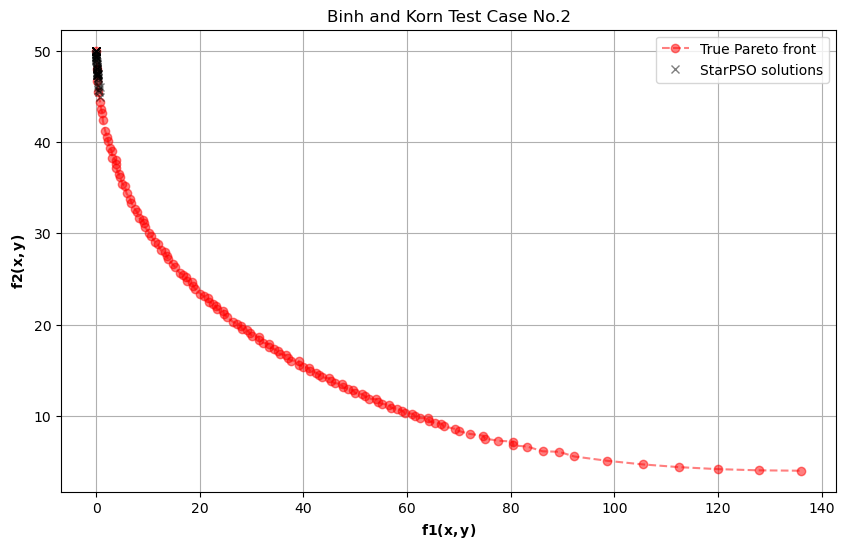

In [24]:
# Create a new figure.
plt.figure(figsize=(10, 6))

# Plot the Pareto front.
plt.plot(pareto_points[:, 0],
         pareto_points[:, 1],
         'ro--', alpha=0.5, label="True Pareto front")

# Plot other points.
plt.plot(best_n[:, 0],
         best_n[:, 1],
         'kx', alpha=0.5, label="StarPSO solutions")

# Tidy up the plot.
plt.title("Binh and Korn Test Case No.2")
plt.xlabel(r"$\mathbf{f1(x,y)}$")
plt.ylabel(r"$\mathbf{f2(x,y)}$")
plt.legend()
plt.grid(True)

plt.savefig("Binh_and_Korn_pareto.pdf", format="pdf", dpi=300)

### End of file